In [1]:
import timm 
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from pathlib import Path
import pandas as pd
import numpy as np
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm   # 新增进度条库
torch.manual_seed(2023)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
f1 = []
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [3]:
def build_model(num_classes = 11):
    return timm.create_model("convnextv2_nano",pretrained=True,num_classes=num_classes).to(device)

def mixup_data(x, y, alpha=1.0):
    '''返回混合后的输入、原始标签a、打乱标签b、混合系数lam'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    '''计算 MixUp 损失'''
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [4]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # 使用 tqdm 包装 dataloader，设置描述信息
    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        images, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.205)
        optimizer.zero_grad()
        outputs = model(images)
        loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        loss.backward()
        optimizer.step()
        
        batch_loss = loss.item()
        running_loss += batch_loss * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_a = (preds == labels_a).sum().item()   ##新增一些数据增强
        correct_b = (preds == labels_b).sum().item()
        batch_correct = lam * correct_a + (1 - lam) * correct_b
        correct += batch_correct
        total += images.size(0)
     
        #total += labels.size(0)
        #correct += (preds == labels).sum().item()
        
        # 更新进度条显示当前 batch 的 loss 和 acc
        pbar.set_postfix({
            'Loss': f'{batch_loss:.4f}',
            'Acc': f'{correct/total:.4f}'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device, epoch, phase="Val"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_pred,all_labels = [],[]
    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [{phase}]", leave=False)
    with torch.no_grad():
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            all_pred.append(torch.argmax(outputs,dim = 1))
            all_labels.append(labels)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{correct/total:.4f}'
            })
    all_pred = torch.cat(all_pred).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()
    if phase == "Val":
        f1.append(f1_score(all_labels, all_pred, average="macro"))
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def resolve_weather_dataset_root():
    """ImageFolder 根目录：环境变量 RAICOM_DATA_ROOT，或 data/raw/dataset / weather_dataset/dataset。"""
    import sys
    for _base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        _src = _base / "src"
        if (_src / "raicom").is_dir() and str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
            break
    from raicom.paths import default_data_root

    return Path(default_data_root(require_existing=True))


def val_transform():
    return transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )


def save_model_checkpoint(path, model, classes):
    torch.save({"state_dict": model.state_dict(), "classes": list(classes)}, path)


def load_model_weights(path, model, device):
    try:
        blob = torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        blob = torch.load(path, map_location=device)
    if isinstance(blob, dict) and "state_dict" in blob:
        model.load_state_dict(blob["state_dict"])
        return blob.get("classes")
    model.load_state_dict(blob)
    return None


@torch.no_grad()
def collect_predictions(model, dataloader, device):
    model.eval()
    all_pred, all_labels = [], []
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_pred.append(torch.argmax(outputs, dim=1).cpu())
        all_labels.append(labels)
    return torch.cat(all_pred).numpy(), torch.cat(all_labels).numpy()


def print_classification_report(name, y_true, y_pred, class_names):
    print(f"\n========== {name} 分类报告 ==========")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    print("混淆矩阵（行=真实标签，列=预测标签）:")
    print(pd.DataFrame(cm, index=class_names, columns=class_names))


@torch.no_grad()
def inference_image_paths(model, image_paths, class_names, device, transform=None):
    from PIL import Image

    if transform is None:
        transform = val_transform()
    tensors = []
    for p in image_paths:
        img = Image.open(p).convert("RGB")
        tensors.append(transform(img))
    batch = torch.stack(tensors, dim=0).to(device)
    logits = model(batch)
    probs = torch.softmax(logits, dim=1)
    top_prob, top_idx = probs.max(dim=1)
    out = []
    for i, p in enumerate(image_paths):
        j = top_idx[i].item()
        out.append(
            {
                "path": str(p),
                "pred_class": class_names[j],
                "confidence": top_prob[i].item(),
            }
        )
    return out


# ---------------------- 5. 分层采样划分函数 ----------------------
def stratified_split(dataset, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_seed=42):
    targets = np.array(dataset.targets)
    classes = np.unique(targets)
    train_idx, val_idx, test_idx = [], [], []
    np.random.seed(random_seed)
    for cls in classes:
        cls_indices = np.where(targets == cls)[0]
        np.random.shuffle(cls_indices)
        n_cls = len(cls_indices)
        n_train = int(round(train_ratio * n_cls))
        n_val = int(round(val_ratio * n_cls))
        n_test = n_cls - n_train - n_val
        if n_test < 0:
            n_test = 0
            n_train = n_cls - n_val
        train_idx.extend(cls_indices[:n_train])
        val_idx.extend(cls_indices[n_train:n_train+n_val])
        test_idx.extend(cls_indices[n_train+n_val:])
    return train_idx, val_idx, test_idx

# ---------------------- 6. 支持不同 transform 的 Subset 包装类 ----------------------
from torch.utils.data import Dataset

class SubsetWithTransform(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform:
            x = self.transform(x)
        # 兜底：如果还不是 Tensor，强制转换
        if not isinstance(x, torch.Tensor):
            from torchvision.transforms import functional as F
            x = F.to_tensor(x)
        return x, y
# ---------------------- 7. 绘图函数 ----------------------
def plot_curves(train_losses, val_losses, train_accs, val_accs, save_path="training_curves_mamba.png"):
    epochs = range(1, len(train_losses) + 1)
    epochs_for_f1 = range(1,len(f1)+1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accs, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accs, 'r-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,3,3)
    plt.plot(epochs_for_f1,f1, 'b-',label = "F1_Score")
    plt.xlabel('Epoch')
    plt.ylabel('F1_Score')
    plt.title('F1_Score')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"训练曲线已保存至 {save_path}")

# ---------------------- 8. 主程序 ----------------------
def main(model=None):
    f1.clear()
    data_root = str(resolve_weather_dataset_root())

    batch_size = 32
    epochs = 50
    lr = 0.0004
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")

    # 数据增强
    # 定义不同的 transform
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    transform_val = val_transform()
    transform_test = val_transform()  # 测试集与验证集一致，不做随机增强

    # 1. 加载整个数据集（不应用 transform，后续用 SubsetWithTransform 分别加）
    full_dataset = datasets.ImageFolder(root=data_root, transform=None)  # 暂不加 transform
    num_classes = len(full_dataset.classes)
    print(f"发现 {num_classes} 个类别: {full_dataset.classes}")
    print(f"总样本数: {len(full_dataset)}")

    # 2. 分层采样划分索引 (训练:验证:测试 = 0.8:0.1:0.1)
    train_idx, val_idx, test_idx = stratified_split(
        full_dataset, 
        train_ratio=0.8, 
        val_ratio=0.1, 
        test_ratio=0.1, 
        random_seed=42
    )
    print(f"训练集大小: {len(train_idx)}, 验证集大小: {len(val_idx)}, 测试集大小: {len(test_idx)}")

    # 3. 用 SubsetWithTransform 分别包装，赋予不同的 transform
    train_dataset = SubsetWithTransform(full_dataset, train_idx, transform=transform_train)
    val_dataset   = SubsetWithTransform(full_dataset, val_idx,   transform=transform_val)
    test_dataset  = SubsetWithTransform(full_dataset, test_idx,  transform=transform_test)

    # 4. 创建 DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    if model is None:
        model = build_model(num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=2.5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer=optimizer, T_max=epochs, eta_min=7.531e-7
    )

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_acc = 0.0
    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch)
        val_loss, val_acc = validate(model, val_loader, criterion, device, epoch, "Val")
        scheduler.step()
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # 打印 epoch 汇总信息（进度条之外）
        print(f"\nEpoch {epoch:03d}/{epochs} | Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}\n")

        if val_acc > best_acc:
            best_acc = val_acc
            save_model_checkpoint(
                "convnext.pth", model, full_dataset.classes
            )
            print(f"  -> 保存最佳模型，验证准确率 {val_acc:.4f}\n")

    ckpt_classes = load_model_weights("convnext.pth", model, device)
    class_names = ckpt_classes if ckpt_classes is not None else full_dataset.classes

    test_loss, test_acc = validate(
        model, test_loader, criterion, device, epoch=0, phase="Test"
    )
    print(f"\n最终测试集 Loss: {test_loss:.4f} | 准确率: {test_acc:.4f}")
    if f1:
        print(f"验证集 macro-F1（最后一轮）: {f1[-1]:.4f}")

    y_true, y_pred = collect_predictions(model, test_loader, device)
    print_classification_report("测试集", y_true, y_pred, class_names)

    plot_curves(train_losses, val_losses, train_accs, val_accs, save_path="convext.png")


使用设备: cuda
发现 11 个类别: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
总样本数: 6862
训练集大小: 5491, 验证集大小: 687, 测试集大小: 684



Epoch 001/50 | Train Loss 0.8700 | Train Acc 0.7451 | Val Loss 0.3780 | Val Acc 0.8690

  -> 保存最佳模型，验证准确率 0.8690




Epoch 002/50 | Train Loss 0.7168 | Train Acc 0.8006 | Val Loss 0.4036 | Val Acc 0.8894

  -> 保存最佳模型，验证准确率 0.8894




Epoch 003/50 | Train Loss 0.5719 | Train Acc 0.8444 | Val Loss 0.3329 | Val Acc 0.8981

  -> 保存最佳模型，验证准确率 0.8981




Epoch 004/50 | Train Loss 0.5403 | Train Acc 0.8524 | Val Loss 0.3047 | Val Acc 0.9039

  -> 保存最佳模型，验证准确率 0.9039



...


Epoch 047/50 | Train Loss 0.3004 | Train Acc 0.8999 | Val Loss 0.2187 | Val Acc 0.9461

  -> 保存最佳模型，验证准确率 0.9461




Epoch 048/50 | Train Loss 0.2806 | Train Acc 0.8961 | Val Loss 0.2239 | Val Acc 0.9432




Epoch 049/50 | Train Loss 0.2996 | Train Acc 0.8944 | Val Loss 0.2221 | Val Acc 0.9432




Epoch 050/50 | Train Loss 0.2944 | Train Acc 0.8932 | Val Loss 0.2229 | Val Acc 0.9432




最终测试集 Loss: 0.2775 | 准确率: 0.9284
验证集 macro-F1（最后一轮）: 0.9470

========== 测试集 分类报告 ==========
              precision    recall  f1-score   support

         dew     0.9571    0.9710    0.9640        69
     fogsmog     0.9412    0.9639    0.9524        83
       frost     0.8723    0.8723    0.8723        47
       glaze     0.8438    0.8571    0.8504        63
        hail     0.9831    0.9667    0.9748        60
   lightning     1.0000    1.0000    1.0000        37
        rain     0.9615    0.9804    0.9709        51
     rainbow     1.0000    1.0000    1.0000        23
        rime     0.9224    0.8770    0.8992       122
   sandstorm     0.9565    0.9429    0.9496        70
        snow     0.8387    0.8814    0.8595        59

    accuracy                         0.9284       684
   macro avg     0.9342    0.9375    0.9357       684
weighted avg     0.9288    0.9284    0.9284       684

混淆矩阵（行=真实标签，列=预测标签）:
           dew  fogsmog  frost  glaze  hail  lightning  rain  rainbow  ri

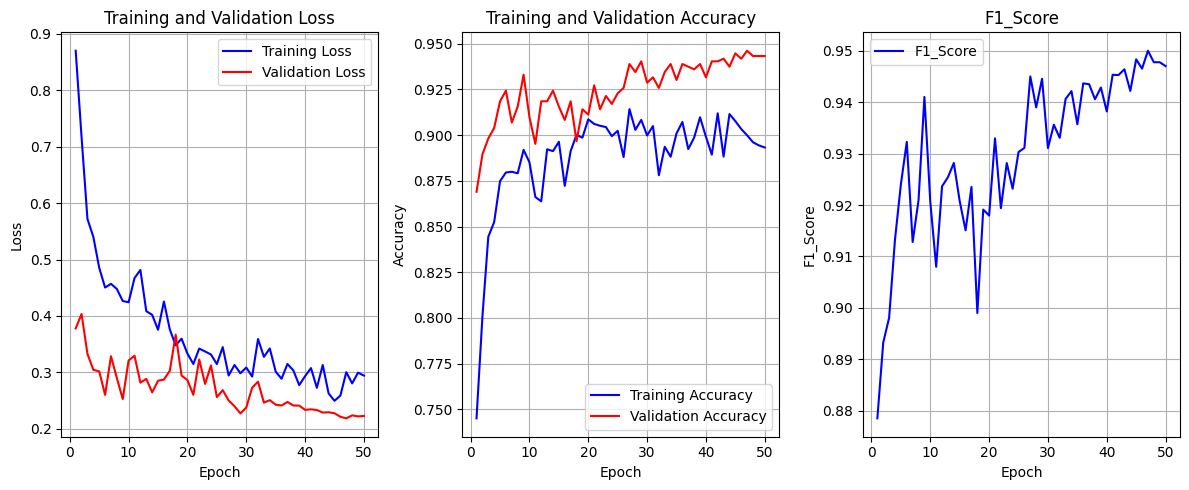

训练曲线已保存至 convext.png


In [5]:
main()